In [20]:
import os
import sys
import argparse

import pandas as pd
import seaborn as sns
import scikit_posthocs as sp
import matplotlib.pyplot as plt


from data import *
from utils import *
from scipy import stats
from datetime import datetime
from scipy.stats import kruskal

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

from BA import oh_binary_accuracy

In [21]:
df = pd.read_csv('./data/Attack-B-Results.csv')

In [22]:
df.head()

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss
0,1V,True,True,0.012069,0.049383,NaN,NaN,NaN,NaN
1,1V,True,True,0.011992,0.048575,NaN,NaN,NaN,NaN
2,1V,True,True,0.011487,0.048137,NaN,NaN,NaN,NaN
3,1V,True,True,0.012184,0.049810,NaN,NaN,NaN,NaN
4,1V,True,True,0.011993,0.049253,NaN,NaN,NaN,NaN


In [24]:
mean_clean_loss = (
    df[
        (df['image_attack'] == True) &
        (df['sketch_attack'] == False)
    ]
    .groupby(['model', 'image_attack', 'sketch_attack'])[
        ['Clean_IM_Loss', 'FGSM_IM_Loss']
    ]
    .mean()
    .reset_index()
)

In [25]:
mean_clean_loss

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss
0,1V,True,False,0.011886,0.048809
1,2V-IL,True,False,0.014399,0.065484
2,2V-IS,True,False,0.015343,0.061183
3,3V,True,False,0.015168,0.220216


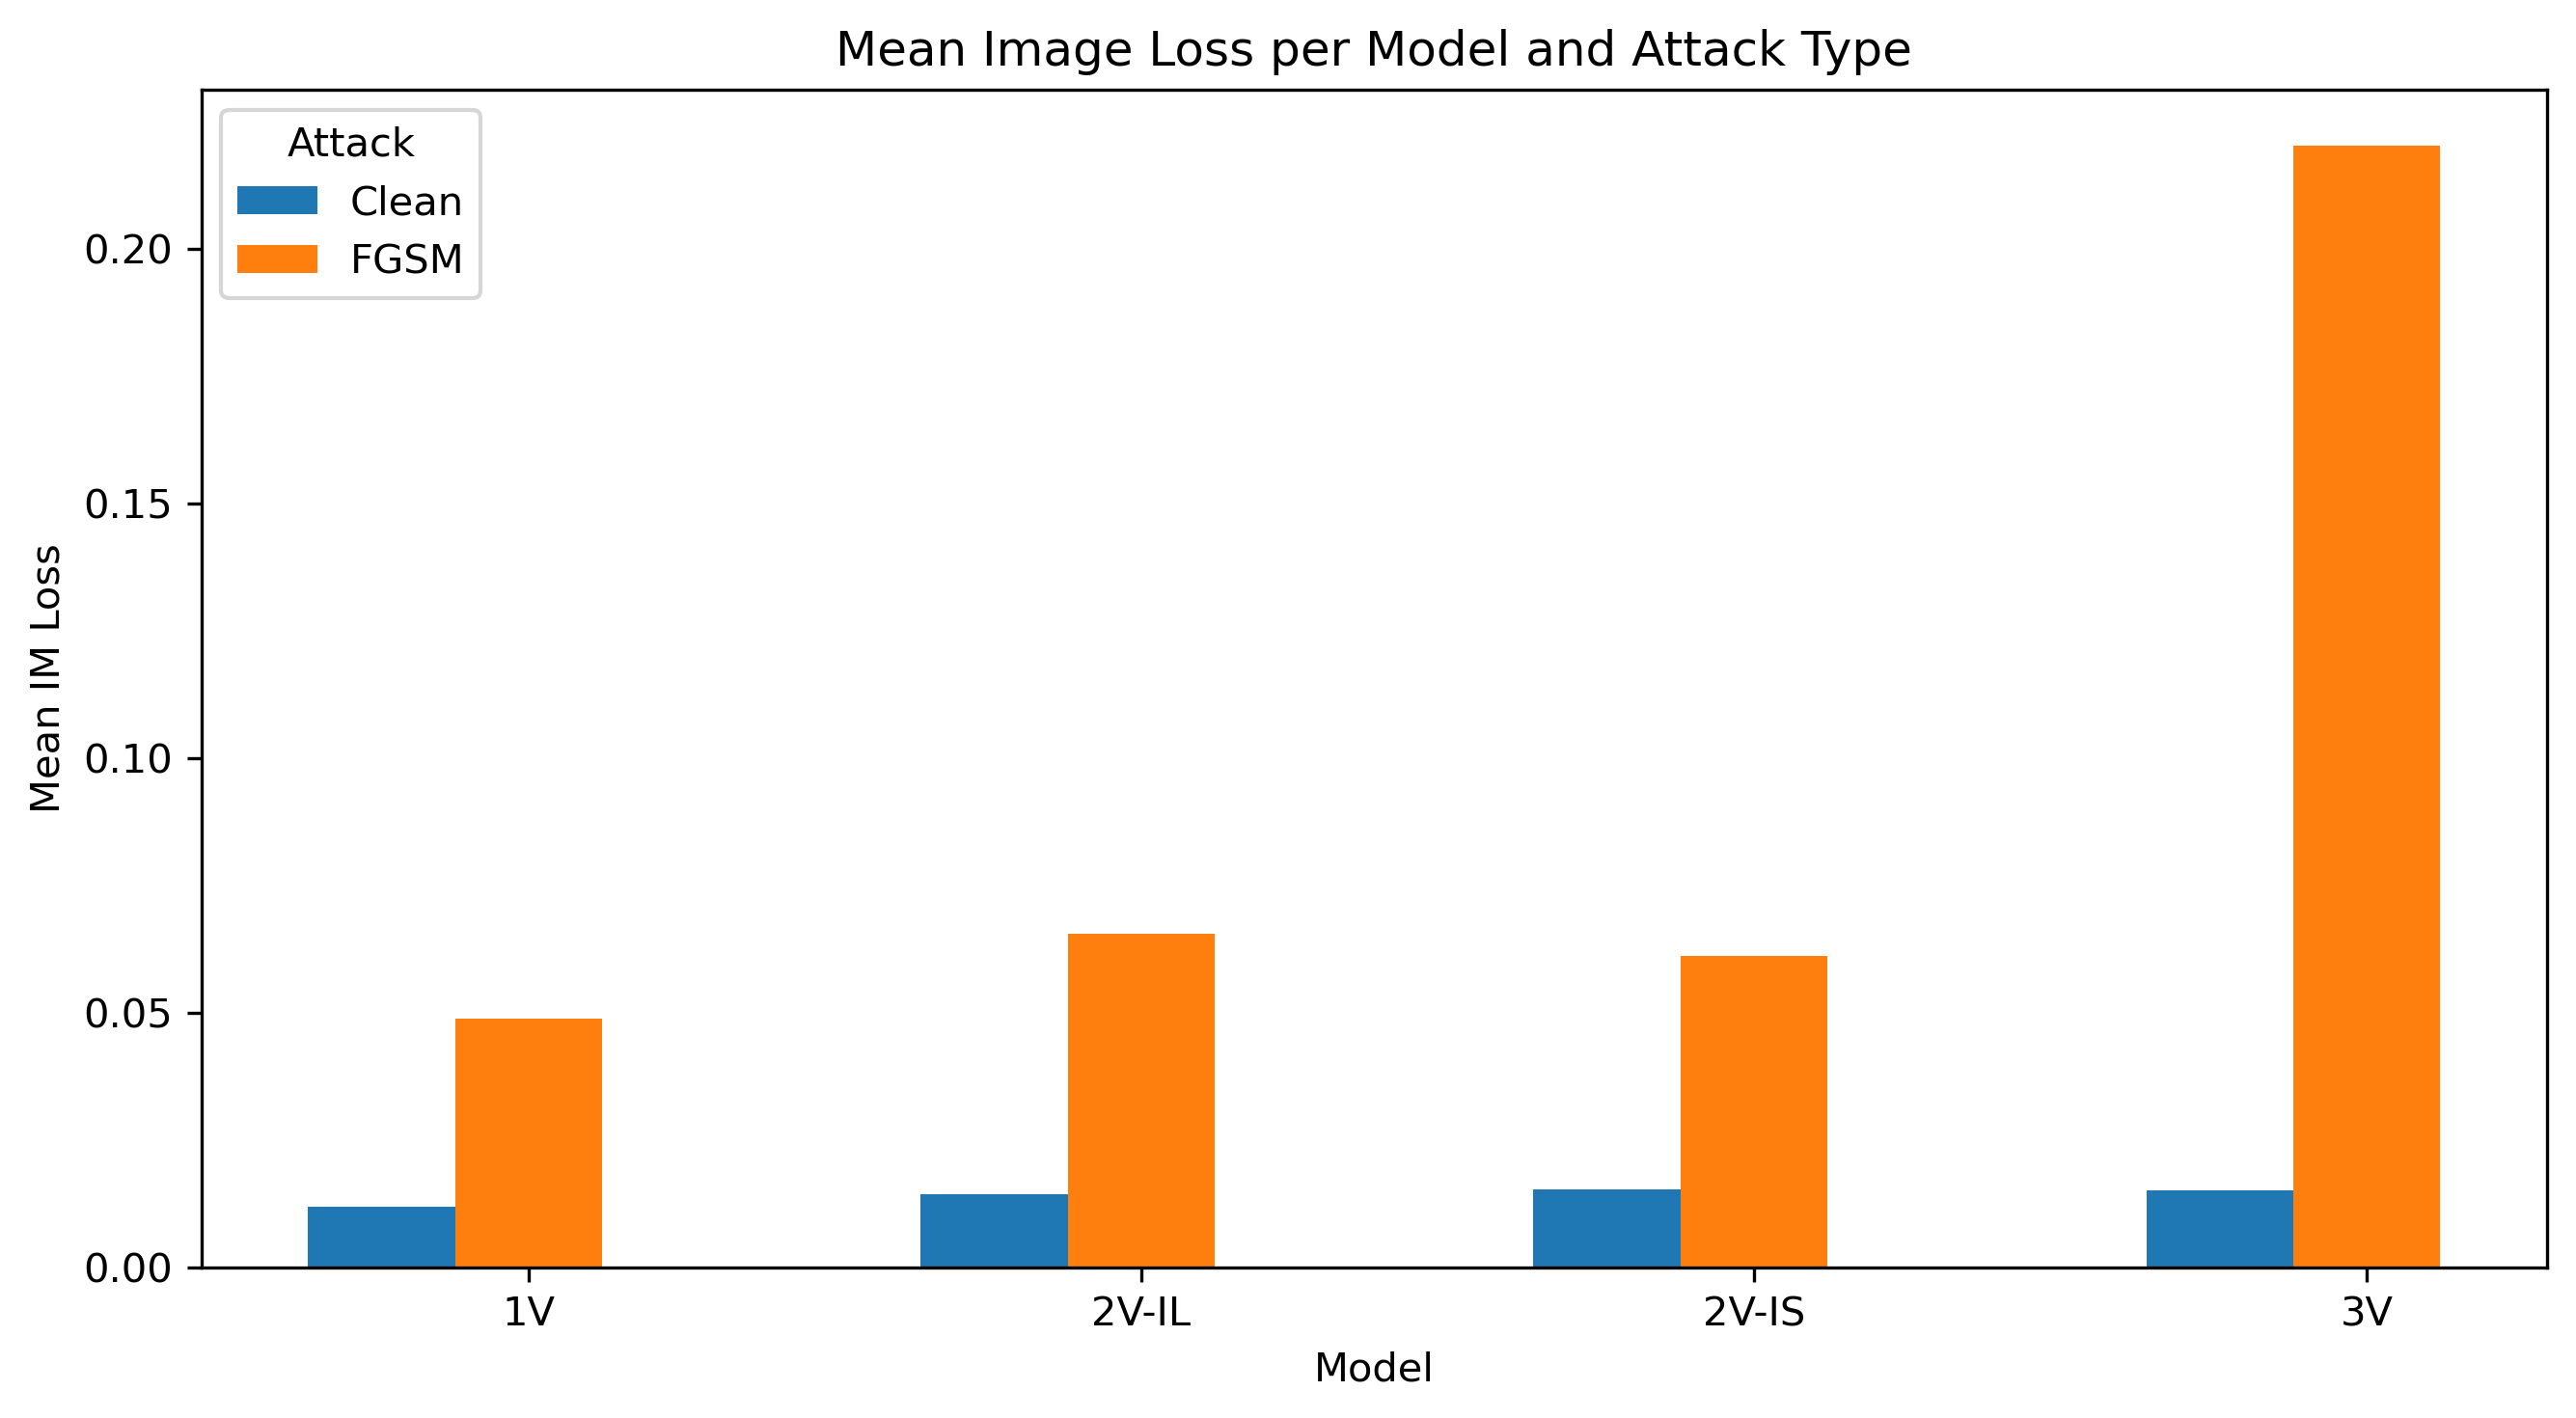

In [27]:
models = mean_clean_loss['model']
clean = mean_clean_loss['Clean_IM_Loss']
fgsm = mean_clean_loss['FGSM_IM_Loss']

x = np.arange(len(models))
width = 0.24

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

ax.bar(x - width, clean, width, label='Clean')
ax.bar(x, fgsm, width, label='FGSM')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_xlabel('Model')
ax.set_ylabel('Mean IM Loss')
ax.set_title('Mean Image Loss per Model and Attack Type')
ax.legend(title='Attack')

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/MT-Dev/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/MT-Dev/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


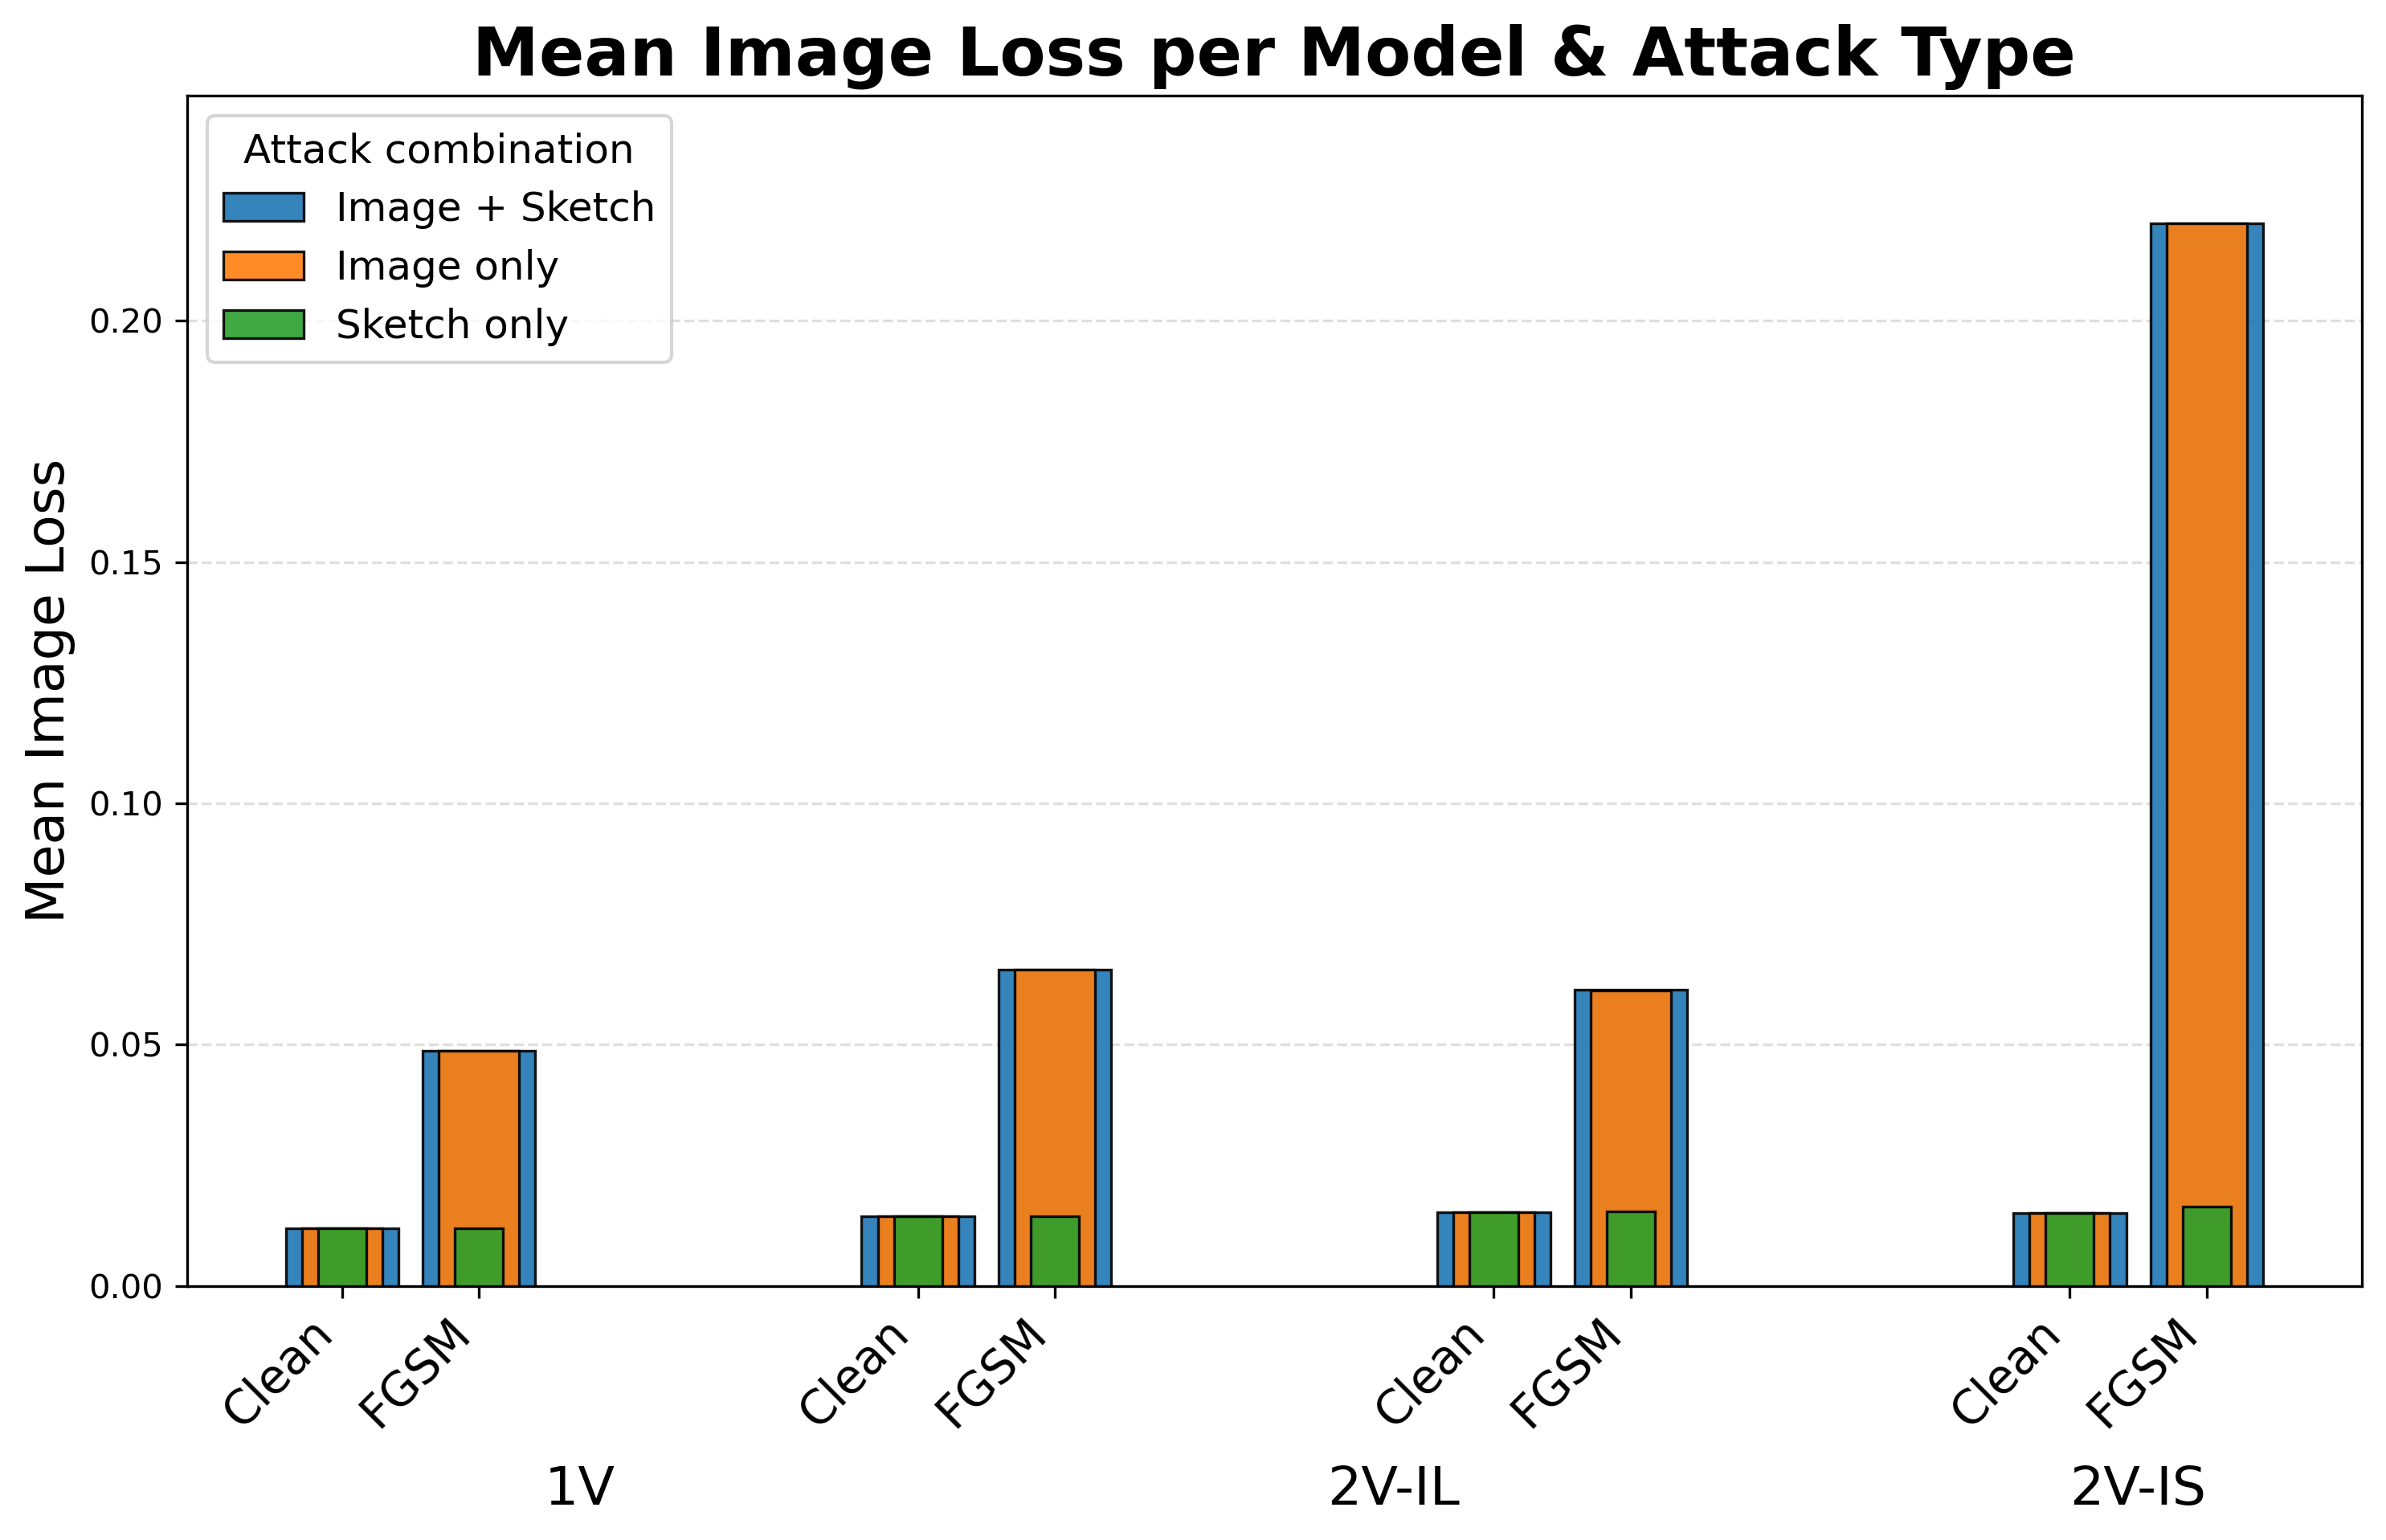

In [28]:
plot_df = (
    df[
        ((df['image_attack'] == True) & (df['sketch_attack'] == True)) |
        ((df['image_attack'] == True) & (df['sketch_attack'] == False)) |
        ((df['image_attack'] == False) & (df['sketch_attack'] == True))
    ]
    .groupby(['model', 'image_attack', 'sketch_attack'])[
        ['Clean_IM_Loss', 'FGSM_IM_Loss']
    ]
    .mean()
    .reset_index()
)

model_order = ['1V', '2V-IL', '2V-IS', '3V']
loss_names = ['Clean', 'FGSM']
loss_col_map = {
    'Clean': 'Clean_IM_Loss',
    'FGSM': 'FGSM_IM_Loss'
}

combo_order = [
    (True, True),    # widest / back
    (True, False),   # middle
    (False, True)    # narrowest / front
]

combo_labels = {
    (True, True): 'Image + Sketch',
    (True, False): 'Image only',
    (False, True): 'Sketch only'
}

# Lookup table
lookup = {}
for _, row in plot_df.iterrows():
    lookup[(row['model'], row['image_attack'], row['sketch_attack'])] = row

# Wider spacing layout
within_gap = 0.34   # space between Clean / FGSM / BIM
group_gap = 0.75    # extra space between models

x_positions = []
x_labels = []
x = 0

for model in model_order:
    for loss in loss_names:
        x_positions.append(x)
        x_labels.append((model, loss))
        x += within_gap
    x += group_gap

# Wider overlapping bars
widths = {
    (True, True): 0.28,
    (True, False): 0.20,
    (False, True): 0.12
}

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)

for i, combo in enumerate(combo_order):
    heights = []
    for model, loss_name in x_labels:
        row = lookup.get((model, combo[0], combo[1]))
        if row is None:
            heights.append(np.nan)
        else:
            heights.append(row[loss_col_map[loss_name]])

    ax.bar(
        x_positions,
        heights,
        width=widths[combo],
        alpha=0.9,
        edgecolor='black',
        linewidth=0.8,
        label=combo_labels[combo],
        zorder=3 + i
    )

# Tick labels
ax.set_xticks(x_positions)
ax.set_xticklabels([loss for _, loss in x_labels], fontsize=14, rotation=45, ha='right')

# Model labels below each block of 3 bars
for i, model in enumerate(model_order):
    start = i * 3
    center = np.mean(x_positions[start:start+3])
    ax.text(
        center, -0.15, model,
        ha='center', va='top',
        transform=ax.get_xaxis_transform(),
        fontsize=16
    )

# Add a bit of headroom so nothing looks cut off
all_vals = []
for row in lookup.values():
    all_vals.extend([row['Clean_IM_Loss'], row['FGSM_IM_Loss']])

ax.set_ylim(0, max(all_vals) * 1.12)

ax.set_ylabel('Mean Image Loss', fontsize=16)
ax.set_title('Mean Image Loss per Model & Attack Type', fontsize=20, fontweight='bold')
ax.legend(title='Attack combination', loc='upper left', fontsize=12, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Clean

In [29]:
mean_clean_loss2 = (
    df[
        (df['image_attack'] == True) &
        (df['sketch_attack'] == False)
    ]
    .groupby(['model', 'image_attack', 'sketch_attack'])[
        ['Clean_IM_Loss', 'FGSM_IM_Loss']
    ]
    .mean()
    .reset_index()
)

In [30]:
df_stat_test = df[
    ((df['model'] == '1V')    & (df['image_attack'] == True) & (df['sketch_attack'] == False)) |
    ((df['model'] == '2V-IL') & (df['image_attack'] == True) & (df['sketch_attack'] == False)) |
    ((df['model'] == '2V-IS') & (df['image_attack'] == True) & (df['sketch_attack'] == False)) |
    ((df['model'] == '3V')    & (df['image_attack'] == True) & (df['sketch_attack'] == False))
].copy()

# Extract the 4 groups
g_1v    = df_stat_test.loc[df_stat_test['model'] == '1V', 'Clean_IM_Loss']
g_2vil  = df_stat_test.loc[df_stat_test['model'] == '2V-IL', 'Clean_IM_Loss']
g_2vis  = df_stat_test.loc[df_stat_test['model'] == '2V-IS', 'Clean_IM_Loss']
g_3v    = df_stat_test.loc[df_stat_test['model'] == '3V', 'Clean_IM_Loss']

# Optional sanity check
print(df_stat_test.groupby('model').size())

# Kruskal-Wallis test
h_stat, p_value = kruskal(g_1v, g_2vil, g_2vis, g_3v)

print(f"H-statistic: {h_stat:.6f}")
print(f"P-value: {p_value:.6e}")

model
1V       10
2V-IL    10
2V-IS    10
3V       10
dtype: int64
H-statistic: 26.499512
P-value: 7.495682e-06


1V       a 
2V-IL     b
2V-IS     b
3V        b
Name: letters, dtype: str


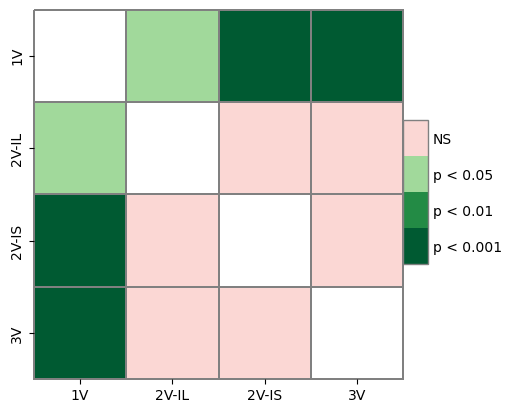

In [31]:
dunn_results = sp.posthoc_dunn(
    df_stat_test,
    val_col='Clean_IM_Loss',
    group_col='model',
    p_adjust='holm'   # or 'holm', 'fdr_bh'
)

heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}
sp.sign_plot(dunn_results, **heatmap_args) # a is significantly different from b

print(sp.compact_letter_display(dunn_results)) # a is significantly different from b
# print(dunn_results)

## FGSM

1V       a  
2V-IL     bc
2V-IS    ab 
3V         c
Name: letters, dtype: str


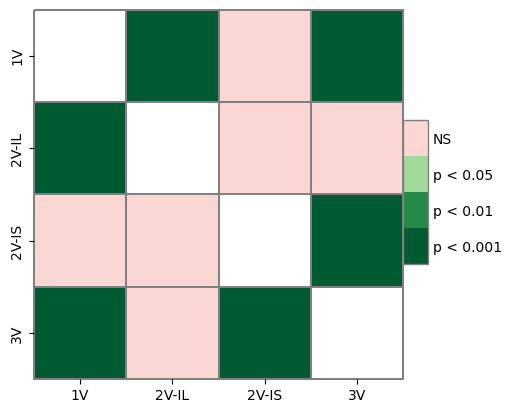

In [32]:
dunn_results = sp.posthoc_dunn(
    df_stat_test,
    val_col='FGSM_IM_Loss',
    group_col='model',
    p_adjust='holm'   # or 'holm', 'fdr_bh'
)

heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}
sp.sign_plot(dunn_results, **heatmap_args) # a is significantly different from b

print(sp.compact_letter_display(dunn_results)) # a is significantly different from b
# print(dunn_results)

## IS VS I only

In [33]:
df_stat_test_2 = df[
    ((df['model'] == '1V')    & (df['image_attack'] == True)) |
    ((df['model'] == '2V-IL') & (df['image_attack'] == True)) |
    ((df['model'] == '2V-IS') & (df['image_attack'] == True)) |
    ((df['model'] == '3V')    & (df['image_attack'] == True))
].copy()

In [34]:
df_stat_test_2.head()

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss
0,1V,True,True,0.012069,0.049383,NaN,NaN,NaN,NaN
1,1V,True,True,0.011992,0.048575,NaN,NaN,NaN,NaN
2,1V,True,True,0.011487,0.048137,NaN,NaN,NaN,NaN
3,1V,True,True,0.012184,0.049810,NaN,NaN,NaN,NaN
4,1V,True,True,0.011993,0.049253,NaN,NaN,NaN,NaN


In [35]:
g_1 = df_stat_test_2.loc[
    (df_stat_test_2['image_attack']) & (df_stat_test_2['sketch_attack'])
].groupby('model')['FGSM_IM_Loss'].apply(list)

g_2 = df_stat_test_2.loc[
    (df_stat_test_2['image_attack']) & ~(df_stat_test_2['sketch_attack'])
].groupby('model')['FGSM_IM_Loss'].apply(list)

In [36]:
g_1

model
1V       [0.0493830738185962, 0.0485748618997604, 0.048...
2V-IL    [0.0654435702447126, 0.0653628154347082, 0.065...
2V-IS    [0.0617440916714291, 0.0609176364970207, 0.060...
3V       [0.2174874652292786, 0.2221368301092133, 0.219...
Name: FGSM_IM_Loss, dtype: object

In [37]:
t_stat, p_value = stats.ttest_rel(g_1.loc['3V'], g_2.loc['3V'])

print(f"T-statistic: {t_stat:.6f}")
print(f"P-value: {p_value:.6e}")

T-statistic: 1.563796
P-value: 1.523034e-01


In [38]:
t_stat, p_value = stats.ttest_rel(g_1.loc['2V-IS'], g_2.loc['2V-IS'])

print(f"T-statistic: {t_stat:.6f}")
print(f"P-value: {p_value:.6e}")

T-statistic: 2.113120
P-value: 6.374595e-02
